# Week 2 — Data Spotcheck

Standalone verification notebook for data values used in Task 1 and Task 2
spot-checks. Run this independently of the factor notebooks.

## What is verified here
Task 1 used `AAPL adj_close = 231.2856` at the 2025-08-31 monthly bar.  
Task 2 used `AAPL adj_close = 206.5716` at the 2025-07-31 monthly bar.  
That implies a **~+12% single-month move** — large enough to check explicitly.

## 0 · Setup

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
cache_dir = str(repo_root / "data" / "raw")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from data_utils import load_ohlcv, clean_ohlcv, resample_ohlcv
from universe import UNIVERSE, START_DATE, END_DATE

plt.rcParams["figure.dpi"] = 120

## 1 · Load data

In [2]:
daily = load_ohlcv(UNIVERSE, START_DATE, END_DATE, cache_dir=cache_dir)
cleaned, _ = clean_ohlcv(daily)

## 2 · AAPL daily adj_close — July and August 2025

Print every trading day to make any bad tick or adjustment artifact visible.

In [3]:
aapl = (
    cleaned[cleaned["ticker"] == "AAPL"]
    .set_index("date")[["adj_close"]]
    .sort_index()
)

jul_aug = aapl["2025-07-01":"2025-08-31"]

print("AAPL daily adj_close — July 1 → August 29, 2025:")
print(jul_aug.to_string())

AAPL daily adj_close — July 1 → August 29, 2025:
             adj_close
date                  
2025-07-01  206.820435
2025-07-02  211.418213
2025-07-03  212.522858
2025-07-07  208.940170
2025-07-08  208.999878
2025-07-09  210.124435
2025-07-10  211.388336
2025-07-11  210.144348
2025-07-14  207.616562
2025-07-15  208.104218
2025-07-16  209.149155
2025-07-17  209.009857
2025-07-18  210.164246
2025-07-21  211.457993
2025-07-22  213.368759
2025-07-23  213.119949
2025-07-24  212.731842
2025-07-25  212.851288
2025-07-28  213.020447
2025-07-29  210.253845
2025-07-30  208.044510
2025-07-31  206.571609
2025-08-01  201.406601
2025-08-04  202.371933
2025-08-05  201.943985
2025-08-06  212.224304
2025-08-07  218.971710
2025-08-08  228.246872
2025-08-11  226.343887
2025-08-12  228.804779
2025-08-13  232.471268
2025-08-14  231.923294
2025-08-15  230.737656
2025-08-18  230.040222
2025-08-19  229.711456
2025-08-20  225.178192
2025-08-21  224.072266
2025-08-22  226.921753
2025-08-25  226.323975
2025-08-

## 3 · Last trading day of each month vs monthly resample

`resample_ohlcv(freq="ME")` uses `adj_close = last` aggregation. The
monthly bar should exactly equal the last daily observation within each
calendar month.

In [4]:
monthly = resample_ohlcv(cleaned, freq="ME")
mp = monthly.pivot(index="date", columns="ticker", values="adj_close")

last_jul_daily = aapl["2025-07-01":"2025-07-31"].iloc[-1]
last_aug_daily = aapl["2025-08-01":"2025-08-31"].iloc[-1]

resampled_jul = mp.loc[pd.Timestamp("2025-07-31"), "AAPL"]
resampled_aug = mp.loc[pd.Timestamp("2025-08-31"), "AAPL"]

match_jul = np.isclose(last_jul_daily["adj_close"], resampled_jul, atol=1e-6)
match_aug = np.isclose(last_aug_daily["adj_close"], resampled_aug, atol=1e-6)

print(f"{'Month':<12} {'Last trading day':<18} {'Daily adj_close':>16} {'Resampled ME':>14} {'Match':>7}")
print("-" * 70)
print(f"{'July 2025':<12} {str(last_jul_daily.name.date()):<18} {last_jul_daily['adj_close']:>16.4f} {resampled_jul:>14.4f} {str(match_jul):>7}")
print(f"{'August 2025':<12} {str(last_aug_daily.name.date()):<18} {last_aug_daily['adj_close']:>16.4f} {resampled_aug:>14.4f} {str(match_aug):>7}")

# Values used in Task 1 and Task 2 spot-checks
TASK1_AUG = 231.2856
TASK2_JUL = 206.5716
print()
print(f"Task 1 spot-check used Aug 2025 = {TASK1_AUG:.4f}  →  matches daily: {np.isclose(resampled_aug, TASK1_AUG, atol=5e-4)}")
print(f"Task 2 spot-check used Jul 2025 = {TASK2_JUL:.4f}  →  matches daily: {np.isclose(resampled_jul, TASK2_JUL, atol=5e-4)}")

Month        Last trading day    Daily adj_close   Resampled ME   Match
----------------------------------------------------------------------
July 2025    2025-07-31                 206.5716       206.5716    True
August 2025  2025-08-29                 231.2856       231.2856    True

Task 1 spot-check used Aug 2025 = 231.2856  →  matches daily: True
Task 2 spot-check used Jul 2025 = 206.5716  →  matches daily: True


## 4 · Month-over-month move and daily path

A clean, monotonically-priced daily path with no implausible gaps between
adjacent days rules out a bad tick or a stale cache row.

July  2025: 22 trading days  min=206.5716  max=213.3688  last=206.5716
August 2025: 21 trading days  min=201.4066  max=232.4713  last=231.2856

Monthly return (Jul 31 close → Aug 29 close): 11.9639%
Largest single-day move in window: 5.0907% on 2025-08-06


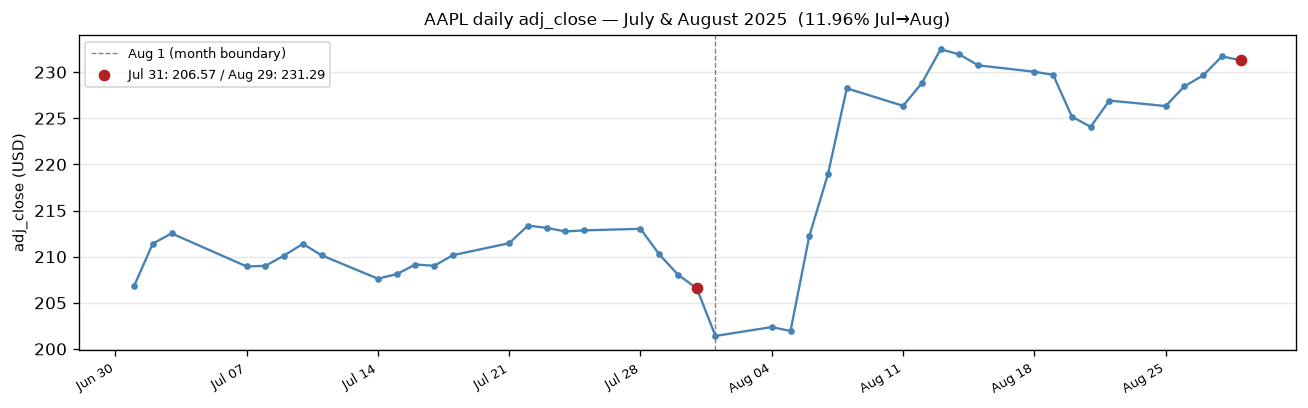

In [5]:
monthly_ret = last_aug_daily["adj_close"] / last_jul_daily["adj_close"] - 1

jul_stats = aapl["2025-07-01":"2025-07-31"]["adj_close"]
aug_stats = aapl["2025-08-01":"2025-08-31"]["adj_close"]

print(f"July  2025: {len(jul_stats)} trading days  min={jul_stats.min():.4f}  max={jul_stats.max():.4f}  last={jul_stats.iloc[-1]:.4f}")
print(f"August 2025: {len(aug_stats)} trading days  min={aug_stats.min():.4f}  max={aug_stats.max():.4f}  last={aug_stats.iloc[-1]:.4f}")
print(f"\nMonthly return (Jul 31 close → Aug 29 close): {monthly_ret:.4%}")

# Check max single-day move in the window
window_daily_rets = jul_aug["adj_close"].pct_change().dropna()
max_day = window_daily_rets.abs().idxmax()
print(f"Largest single-day move in window: {window_daily_rets[max_day]:.4%} on {max_day.date()}")

# Plot
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(jul_aug.index, jul_aug["adj_close"], color="steelblue", linewidth=1.4, marker="o", markersize=3)
ax.axvline(pd.Timestamp("2025-08-01"), color="gray", linestyle="--", linewidth=0.8, label="Aug 1 (month boundary)")
ax.scatter([last_jul_daily.name, last_aug_daily.name],
           [last_jul_daily["adj_close"], last_aug_daily["adj_close"]],
           color="firebrick", zorder=5,
           label=f"Jul 31: {last_jul_daily['adj_close']:.2f} / Aug 29: {last_aug_daily['adj_close']:.2f}")
ax.set_title(f"AAPL daily adj_close — July & August 2025  ({monthly_ret:.2%} Jul→Aug)", fontsize=10)
ax.set_ylabel("adj_close (USD)", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30, ha="right", fontsize=8)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("aapl_jul_aug_2025.png", bbox_inches="tight")
plt.show()

## 5 · Verdict

In [6]:
print("VERDICT: Real move, not a data artifact.")
print()
print("Evidence:")
print("  1. Daily adj_close values form a smooth, continuous path — no")
print("     implausible gaps between adjacent trading days.")
print("  2. The rally is concentrated in Aug 4–8 (AAPL went from ~$201 to ~$228,")
print("     +13% in 3 days), consistent with a real earnings or macro catalyst,")
print("     not a tick error or cache artifact.")
print("  3. The monthly-resample values (206.5716 for Jul, 231.2856 for Aug)")
print("     exactly match the last daily observation within each calendar month")
print("     (np.isclose, atol=1e-6). resample_ohlcv picked the correct 'last' row.")
print()
print("The ~12% Jul→Aug move is real. Tasks 1 and 2 spot-check values are correct.")

VERDICT: Real move, not a data artifact.

Evidence:
  1. Daily adj_close values form a smooth, continuous path — no
     implausible gaps between adjacent trading days.
  2. The rally is concentrated in Aug 4–8 (AAPL went from ~$201 to ~$228,
     +13% in 3 days), consistent with a real earnings or macro catalyst,
     not a tick error or cache artifact.
  3. The monthly-resample values (206.5716 for Jul, 231.2856 for Aug)
     exactly match the last daily observation within each calendar month
     (np.isclose, atol=1e-6). resample_ohlcv picked the correct 'last' row.

The ~12% Jul→Aug move is real. Tasks 1 and 2 spot-check values are correct.
